# Empirical Example for Sensitivity Analysis: 401(k) Eligibility and Financial Wealth

This is an adaptation of the replication package for Chernozhukov, Cinelli, Newey, Sharma and Syrgkanis,
*Long Story Short: Omitted Variable Bias in Causal Machine Learning* 

The original replication package can be found __[here](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/VH6QHQ)__.

In [1]:
# Install packages if needed
repos <- c(CRAN = "https://cloud.r-project.org")

if (!requireNamespace("remotes", quietly = TRUE))   install.packages("remotes", repos = repos)
if (!requireNamespace("sensemakr", quietly = TRUE)) install.packages("sensemakr", repos = repos)
if (!requireNamespace("ggplot2", quietly = TRUE))   install.packages("ggplot2", repos = repos)
if (!requireNamespace("ranger", quietly = TRUE))    install.packages("ranger", repos = repos)
if (!requireNamespace("dml.sensemakr", quietly = TRUE)) {
  remotes::install_github("carloscinelli/dml.sensemakr", upgrade = "never")
}

In [ ]:
suppressMessages({
  library(sensemakr)       # attached first: we only need add_bound_to_contour()
  library(dml.sensemakr)   # attached last:  keeps its methods for class "dml" unmasked
  library(ggplot2)
})

options(scipen = 99)  

# figure sizing inside the notebook
options(repr.plot.width = 7, repr.plot.height = 6, repr.plot.res = 150)

dir.create("figures", showWarnings = FALSE)

cat("dml.sensemakr", as.character(packageVersion("dml.sensemakr")), "\n")
cat("sensemakr    ", as.character(packageVersion("sensemakr")), "\n")

dml.sensemakr 0.2.2 


sensemakr     0.1.6 


## Setting

The outcome $Y$ is net financial assets and the treatment $D$ is eligibility to enroll in a 401(k) plan. The observed covariates $X^o$ include income, age, education, family size, marital status, two-earner status, IRA participation, and home ownership. The identifying argument used in earlier work is that, after conditioning on these worker characteristics, eligibility is approximately as good as randomly assigned.

However, the threat is that unobserved firm characteristics $A$ may affect both eligibility and financial assets, for example through employer matching policies. Conditional ignorability then holds given the full $X = (X^o, A)$, while the data identify only functions of the short regressor vector $W_s = (D, X^o)$. What we can estimate is the short parameter $\theta_s$. The task is to bound its
distance from the causal target $\theta$.

In [3]:
data("pension")

y <- pension$net_tfa   # Y: net total financial assets
d <- pension$e401      # D: 401(k) eligibility

# X^o: the observed worker characteristics
x <- model.matrix(~ -1 + age + inc + educ + fsize + marr + twoearn + pira + hown,
                  data = pension)

cat("households:", nrow(x), "  covariates:", ncol(x),
    "  eligible:", sprintf("%.1f%%", 100 * mean(d)), "\n")

households: 9915   covariates: 8   eligible: 37.1% 


## Short Estimates Under Conditional Ignorability

### Partially Linear Model

The first specification is the partially linear model,

$$Y = \theta_s D + f_s(X^o) + \varepsilon, \qquad \mathrm{E}[\varepsilon \mid D, X^o] = 0,$$

with the nuisance functions modeled by random forests, cross-fitted over five folds and repeated five times.

In [4]:
set.seed(1)
dml.401k.plm <- dml(y, d, x, model = "plm", cf.folds = 5, cf.reps = 5, verbose = FALSE)

summary(dml.401k.plm)


Debiased Machine Learning

 Model: Partially Linear 
 Cross-Fitting: 5 folds, 5 reps 
 ML Method: outcome (yreg0:ranger, yreg1:ranger, R2 = 26.663%), treatment (ranger, R2 = 11.588%)
 Tuning: dirty 

Average Treatment Effect : 

    Estimate Std. Error t value          P(>|t|)    
ate     9038       1326   6.815 0.00000000000944 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
Note: DML estimates combined using the median method.

Verbal interpretation of DML procedure:

-- Average treatment effects were estimated using DML with 5-fold cross-fitting. In order to reduce the variance that stems from sample splitting, we repeated the procedure 5 times. Estimates are combined using the median as the final estimate, incorporating variation across experiments into the standard error as described in Chernozhukov et al. (2018). The outcome regression uses Random Forest from the R package ranger; the treatment regression uses Random Forest from the R package ranger.

### Nonparametric Model, with Income Groups

The second specification drops the additive structure. The short regression
$g_s(W_s) = \mathrm{E}[Y \mid D, X^o]$ is left unrestricted and the target is the average contrast,

$$\theta_s = \mathrm{E}\big\{g_s(1, X^o) - g_s(0, X^o)\big\},$$

estimated with the same nuisance learners. 

In [5]:
# income quartiles
g1 <- cut(x[, "inc"],
          quantile(x[, "inc"], c(0, 0.25, 0.5, 0.75, 1), na.rm = TRUE),
          labels = c("q1", "q2", "q3", "q4"), include.lowest = TRUE)

In [6]:
set.seed(1)
dml.401k.npm <- dml(y, d, x, groups = g1, model = "npm",
                    cf.folds = 5, cf.reps = 5, verbose = FALSE)

summary(dml.401k.npm)


Debiased Machine Learning

 Model: Nonparametric 
 Cross-Fitting: 5 folds, 5 reps 
 ML Method: outcome (yreg0:ranger, yreg1:ranger, R2 = 25.821%), treatment (ranger, R2 = 11.499%)
 Tuning: dirty 

Average Treatment Effect : 

    Estimate Std. Error t value          P(>|t|)    
ate     8252       1187    6.95 0.00000000000365 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Group Average Treatment Effect: 

         Estimate Std. Error t value      P(>|t|)    
g.ate.q1   4560.8      806.8   5.653 0.0000000158 ***
g.ate.q2   2801.4     1310.0   2.139     0.032474 *  
g.ate.q3   6806.1     1835.0   3.709     0.000208 ***
g.ate.q4  18597.4     4071.7   4.567 0.0000049363 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Note: DML estimates combined using the median method.

Verbal interpretation of DML procedure:

-- Average treatment effects were estimated using DML with 5-fold cross-fitting. In order to reduce the variance that stems from sa

## Group Effects by Income Quartile

Plotted against income quartile, with sampling confidence bounds under conditional ignorability,
the pattern in the summary above is easier to read.


In [7]:
group.names <- setdiff(names(coef(dml.401k.npm)), "ate")

df  <- data.frame(groups = 1:4, estimate = coef(dml.401k.npm)[group.names])
cis <- setNames(as.data.frame(confint(dml.401k.npm)[group.names, ]), c("lwr.ci", "upr.ci"))
df  <- cbind(df, cis)

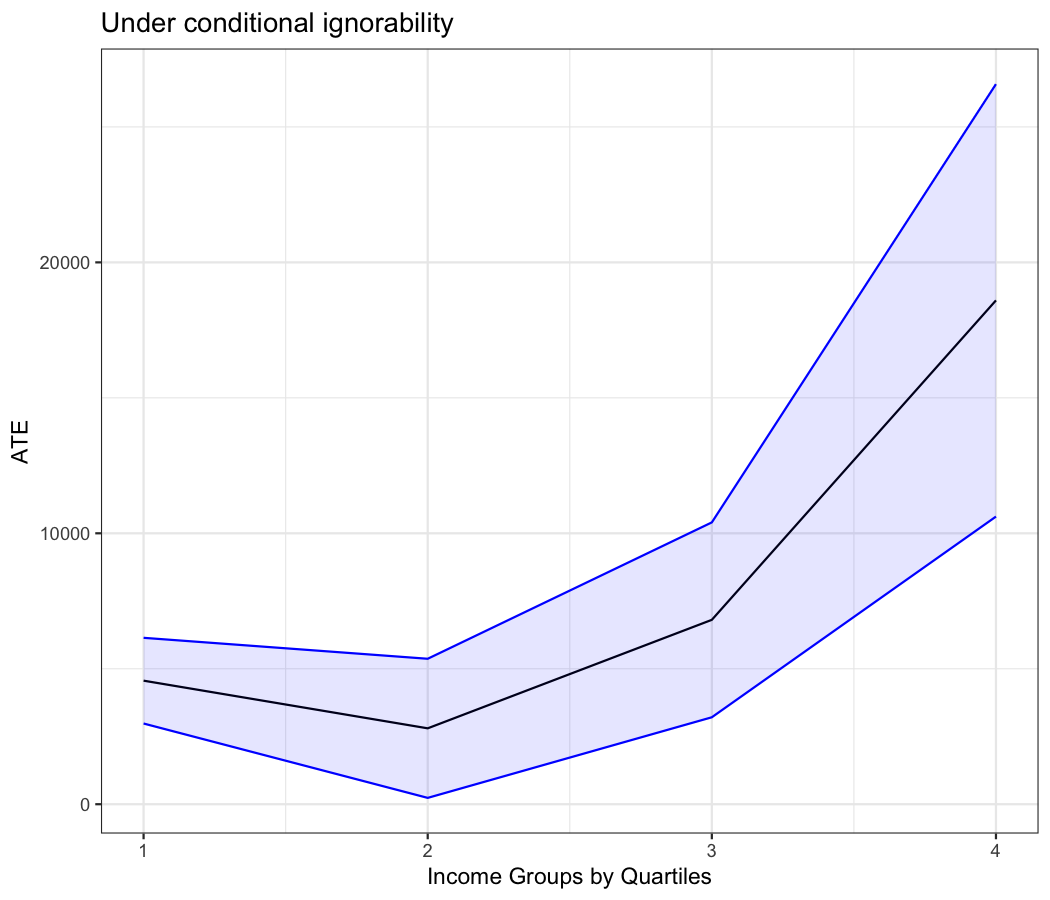

In [8]:
p1 <- ggplot(df, aes(x = groups, y = estimate)) +
  geom_line() +
  geom_ribbon(aes(ymin = lwr.ci, ymax = upr.ci), alpha = 0.1, col = "blue", fill = "blue") +
  theme_bw() +
  xlab("Income Groups by Quartiles") +
  ylab("ATE") +
  ggtitle("Under conditional ignorability")

ggsave("figures/401K-groups-noconfounding.pdf", p1, width = 4.5, height = 4.5)
p1

In [68]:
rv.plm <- robustness_value(dml.401k.plm)
rv.npm <- robustness_value(dml.401k.npm)

cat(sprintf("RV_alpha  (alpha = 0.05, threshold theta = 0)\n  partially linear : %.1f%%\n  nonparametric    : %.1f%%\n",
            100 * rv.plm["ate"], 100 * rv.npm["ate"]))


RV_alpha  (alpha = 0.05, threshold theta = 0)
  partially linear : 5.5%
  nonparametric    : 4.7%


## The Main Confounding Scenario

The main scenario assumes that omitted firm characteristics explain as much outcome variation as the
maximum employer match accumulated over three years, which implies approximately $C_Y^2 = 0.04$. On
the treatment side it allows an additional 2.5 percentage points of eligibility variation beyond the
observed controls, corresponding to $q_\alpha \approx 0.03$. We take $|\rho| = 1$, the conservative
case in which the two induced errors are perfectly aligned.

What $q_\alpha$ measures depends on the target: for the partially linear model it is the
nonparametric partial $R^2$ of the treatment with the omitted covariates, and for the
binary-treatment ATE a gain in average inverse-variance precision.


In [10]:
cf.y <- 0.04   # C_Y^2
cf.d <- 0.03   # q_alpha
rho2 <- 1      # |rho| = 1

bounds.plm <- dml_bounds(dml.401k.plm, cf.y = cf.y, cf.d = cf.d, rho2 = rho2)

In [11]:
bounds.npm <- dml_bounds(dml.401k.npm, cf.y = cf.y, cf.d = cf.d, rho2 = rho2)

In [12]:
cb.plm <- confidence_bounds(dml.401k.plm, cf.y = cf.y, cf.d = cf.d, rho2 = rho2)
cb.npm <- confidence_bounds(dml.401k.npm, cf.y = cf.y, cf.d = cf.d, rho2 = rho2)

In [13]:
dollars <- function(v) formatC(round(v), format = "d", big.mark = ",")

row <- function(bounds, cb, label) {
  b <- coef(bounds)[, "ate"]
  data.frame(
    Model              = label,
    `Short ATE`        = dollars(b["theta.s"]),
    `Bias bound`       = dollars(b["bias.bound"]),
    `ATE bounds`       = sprintf("[%s, %s]", dollars(b["theta.m"]), dollars(b["theta.p"])),
    `95% conf. bounds` = sprintf("[%s, %s]", dollars(cb["ate", 1]), dollars(cb["ate", 2])),
    row.names = NULL,
    check.names = FALSE
  )
}

table2.3 <- rbind(row(bounds.plm, cb.plm, "Partially linear"),
                  row(bounds.npm, cb.npm, "Nonparametric"))

table2.3


Model,Short ATE,Bias bound,ATE bounds,95% conf. bounds
<chr>,<chr>,<chr>,<chr>,<chr>
Partially linear,"9,038","4,195","[4,845, 13,231]","[2,636, 15,514]"
Nonparametric,"8,253","4,533","[3,709, 12,796]","[1,695, 14,851]"


Even granting an adversarially aligned confounder as strong as three years of maximum employer match,
the lower confidence bound on the ATE remains positive in both specifications.

### Group Effects Under the Scenario

The same groups again, now with the sensitivity bounds in red and the wider confidence bounds in
blue.


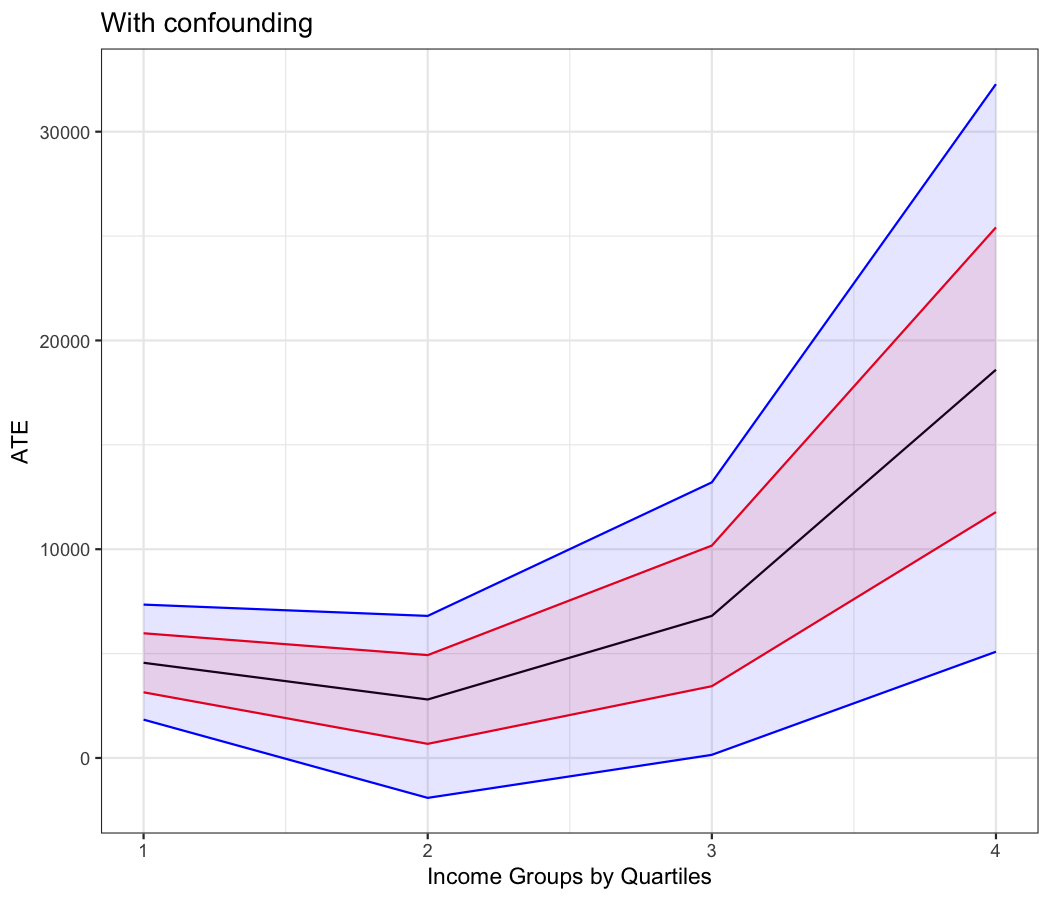

In [ ]:
bds  <- setNames(as.data.frame(confidence_bounds(dml.401k.npm, cf.y = cf.y, cf.d = cf.d, level = 0)),
                 c("lwr.bound", "upr.bound"))
cbds <- setNames(as.data.frame(confidence_bounds(dml.401k.npm, cf.y = cf.y, cf.d = cf.d, level = 0.95)),
                 c("lwr.cbound", "upr.cbound"))

df2 <- cbind(df, bds[-1, ], cbds[-1, ])

p2 <- ggplot(df2, aes(x = groups, y = estimate)) +
  geom_line() +
  geom_ribbon(aes(ymin = lwr.bound,  ymax = upr.bound),  alpha = 0.1, col = "red",  fill = "red") +
  geom_ribbon(aes(ymin = lwr.cbound, ymax = upr.cbound), alpha = 0.1, col = "blue", fill = "blue") +
  theme_bw() +
  xlab("Income Groups by Quartiles") +
  ylab("ATE") +
  ggtitle("With confounding")

ggsave("figures/401K-groups-confounding.pdf", p2, width = 4.5, height = 4.5)
p2

The posited confounding scenario substantially widens the range of plausible effects but leaves most of the adjusted region positive. Only the second quartile has a small excursion below zero.

## Benchmarking

Rather than posit $C_Y$ and $C_D$ in the abstract, we can calibrate them against a covariate we do observe. The procedure is as follows: drop the covariate from $X^o$, refit, and read off the gains it supplied. Latent confounding is then described relative to the chosen benchmarking variable.

In [15]:
set.seed(2)
invisible(capture.output(
  bench.plm <- dml_benchmark(dml.401k.plm,
                             benchmark_covariates = c("inc", "pira", "twoearn"))
))


`gain.Y` is the implied $C_Y^2$ and `gain.D` the implied $q_\alpha$. Income is a strong predictor of both eligibility and financial assets; IRA participation and two-earner status are considerably weaker.

The `rho` column records the alignment each covariate actually exhibits. None is anywhere near $\pm 1$, which is a first indication of how conservative the worst-case analysis is.


In [16]:
out <- summary(bench.plm)$benchmarks
round(out[, c("gain.Y", "gain.D", "rho")], 4)

,gain.Y,gain.D,rho
inc,0.1410,0.0503,-0.3266
pira,0.0476,0.0075,-0.1980
twoearn,0.0481,0.0106,0.2931


## Contour Plots

In [ ]:
bumps.plm <- list(pira    = c(0.010,  0.009),
                  twoearn = c(0.020, -0.002),
                  inc     = c(0.010,  0.009),
                  inc4    = c(0.015, -0.005))

bumps.npm <- list(pira    = c(0.005,  0.009),
                  twoearn = c(0.020,  0.005),
                  inc     = c(-0.010, 0.009),
                  inc4    = c(0.015,  0.000))

contour_panel <- function(fit, bench, rho2, title, bumps = bumps.plm) {
  ovb_contour_plot(fit,
                   which.bound   = "lwr",
                   cf.y          = NULL,
                   rho2          = rho2,
                   col.contour   = "blue",
                   label.bump.x  = 0.015,
                   label.bump.y  = 0.003,
                   lim.x         = 0.16)
  title(main = title)

  add_bound <- function(cfd, cfy, label, bump.x, bump.y, ...) {
    sensemakr::add_bound_to_contour(
      r2dz.x = cfd, r2yz.dx = cfy,
      bound_label = label,
      bound_value = confidence_bounds(fit, cf.y = cfy, cf.d = cfd, rho2 = rho2),
      label.bump.x = bump.x, label.bump.y = bump.y, ...)
  }

  add_bound(0.03, 0.04, "Max Match", 0.015, 0.003, point.pch = 25, point.bg = "red")

  # one-times each observed benchmark
  add_bound(bench["pira",    "gain.D"], bench["pira",    "gain.Y"], "1 x Part. in IRA",
            bumps$pira[1], bumps$pira[2])
  add_bound(bench["twoearn", "gain.D"], bench["twoearn", "gain.Y"], "1 x Two Earners",
            bumps$twoearn[1], bumps$twoearn[2])
  add_bound(bench["inc",     "gain.D"], bench["inc",     "gain.Y"], "1 x Income",
            bumps$inc[1], bumps$inc[2])

  # a quarter as strong as income
  add_bound(bench["inc", "gain.D"] * 0.25, bench["inc", "gain.Y"] * 0.25, "1/4 x Income",
            bumps$inc4[1], bumps$inc4[2])

  invisible(NULL)
}

### Partially Linear Model


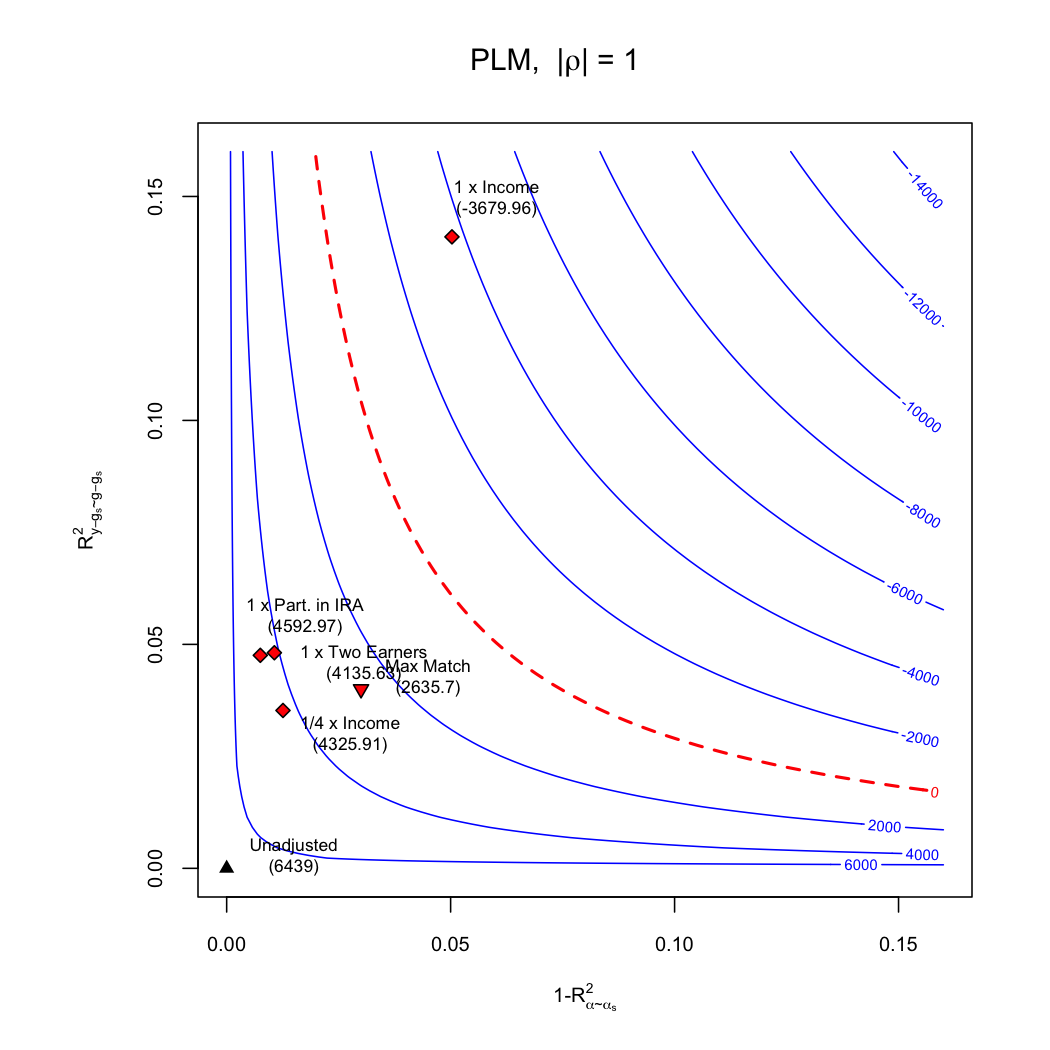

In [18]:
options(repr.plot.width = 7, repr.plot.height = 7)

pdf("figures/401K-contour-plm-lower.pdf", width = 6, height = 6)
contour_panel(dml.401k.plm, out, rho2 = 1, title = expression(paste("PLM,  |", rho, "| = 1")))
invisible(dev.off())

contour_panel(dml.401k.plm, out, rho2 = 1, title = expression(paste("PLM,  |", rho, "| = 1")))

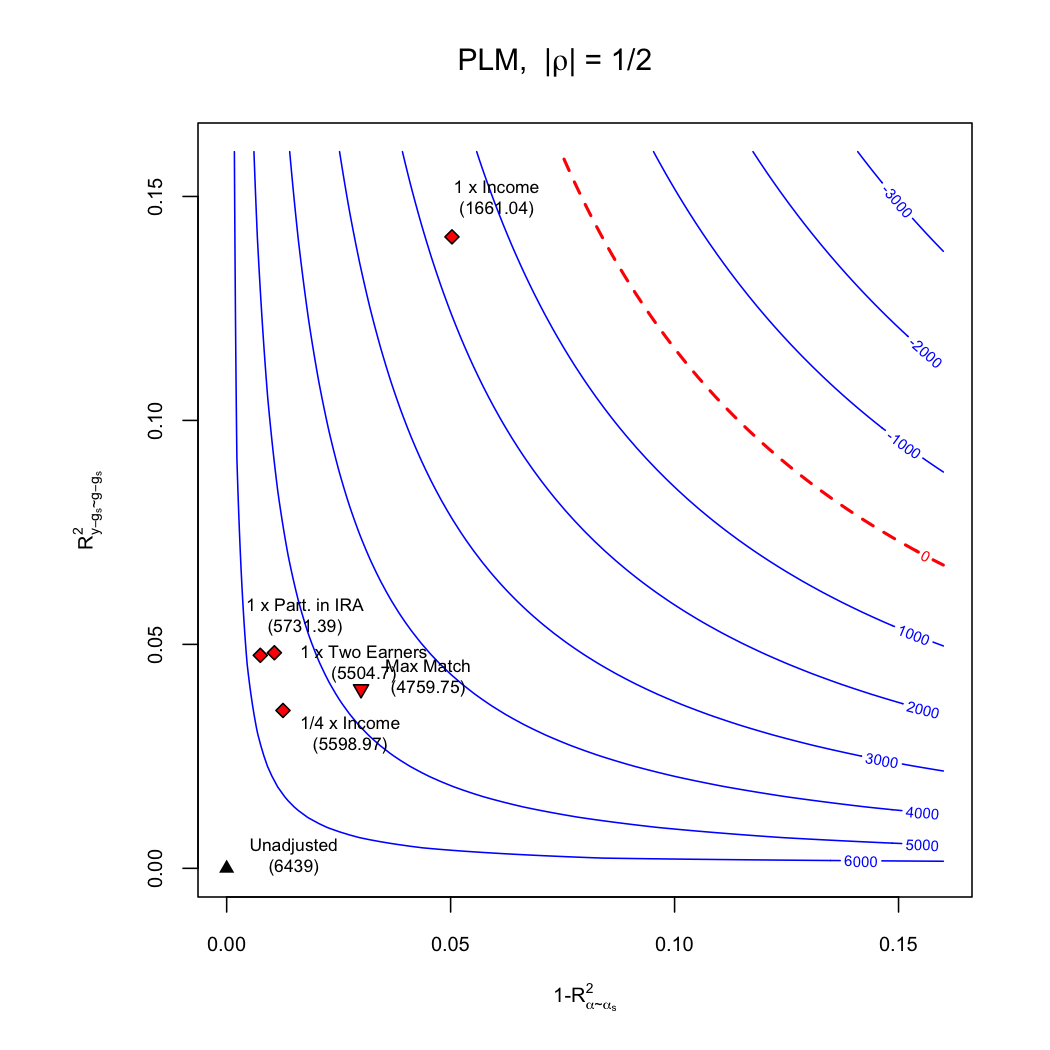

In [19]:
rho2.half <- (1/2)^2

pdf("figures/401K-contour-plm-lower-rho2.pdf", width = 6, height = 6)
contour_panel(dml.401k.plm, out, rho2 = rho2.half, title = expression(paste("PLM,  |", rho, "| = 1/2")))
invisible(dev.off())

contour_panel(dml.401k.plm, out, rho2 = rho2.half, title = expression(paste("PLM,  |", rho, "| = 1/2")))

Under worst-case alignment a confounder as strong as income crosses the zero contour, whereas the matching scenario and the one-quarter-income benchmark do not.

The second panel makes a different assumption: errors in the outcome regression and in the Riesz representer are only half as aligned. The lower endpoint then rises substantially. This comparison separates the strength of a confounder from the degree of adversity with which its two effects align, and none of the observed covariates exhibits alignment close to the worst case.


### Nonparametric Model

The gains are target-specific, so this specification needs its own benchmarks. Here `gain.D` is read as a relative gain in propensity-score precision rather than as a reduction in residual treatment variance.


In [20]:
set.seed(2)
invisible(capture.output(
  bench.npm <- dml_benchmark(dml.401k.npm,
                             benchmark_covariates = c("inc", "pira", "twoearn"))
))

out.npm <- summary(bench.npm)$benchmarks
round(out.npm[, c("gain.Y", "gain.D", "rho")], 4)

,gain.Y,gain.D,rho
inc,0.1337,0.1324,-0.221
pira,0.0231,0.0000,0.000
twoearn,0.0082,0.0000,0.000


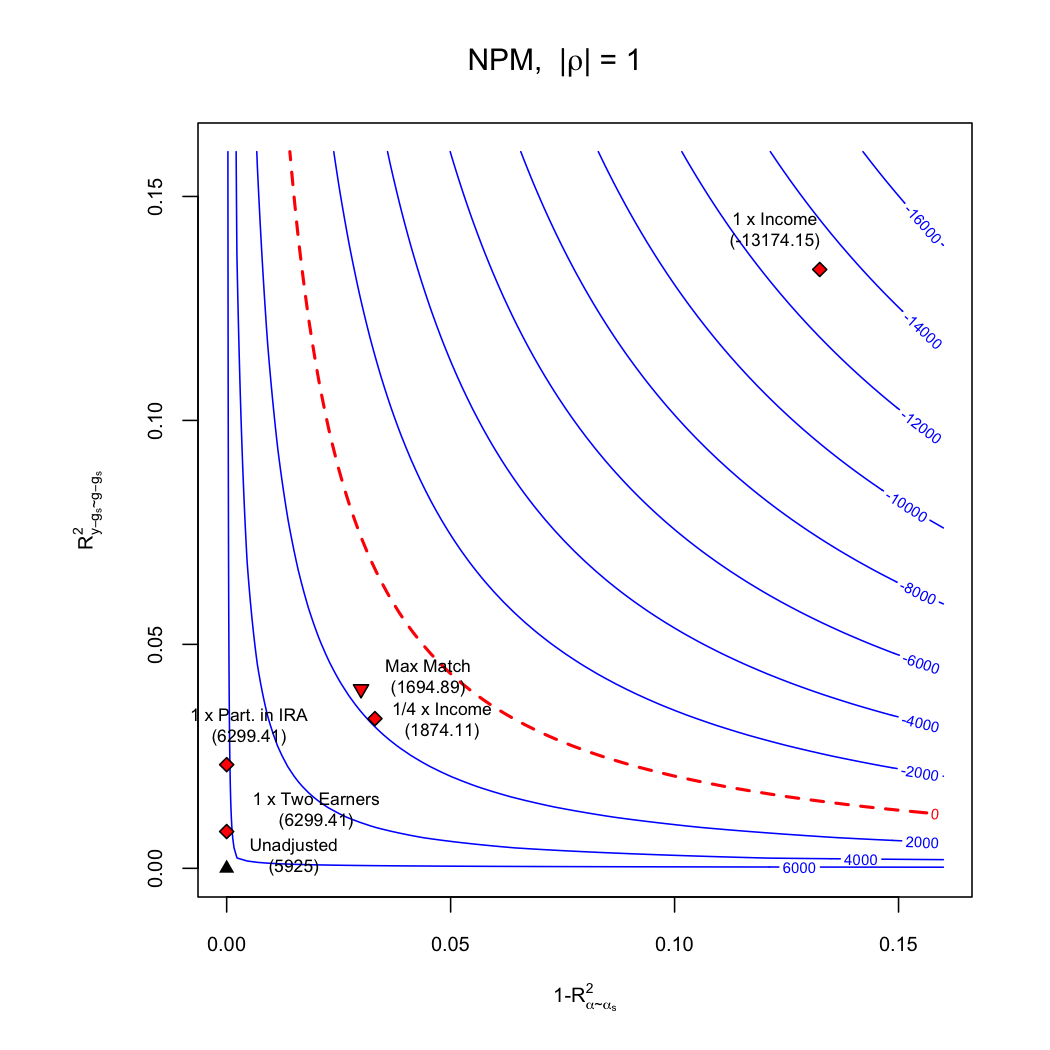

In [21]:
pdf("figures/401K-contour-npm-lower.pdf", width = 6, height = 6)
contour_panel(dml.401k.npm, out.npm, rho2 = 1, title = expression(paste("NPM,  |", rho, "| = 1")), bumps = bumps.npm)
invisible(dev.off())

contour_panel(dml.401k.npm, out.npm, rho2 = 1, title = expression(paste("NPM,  |", rho, "| = 1")), bumps = bumps.npm)

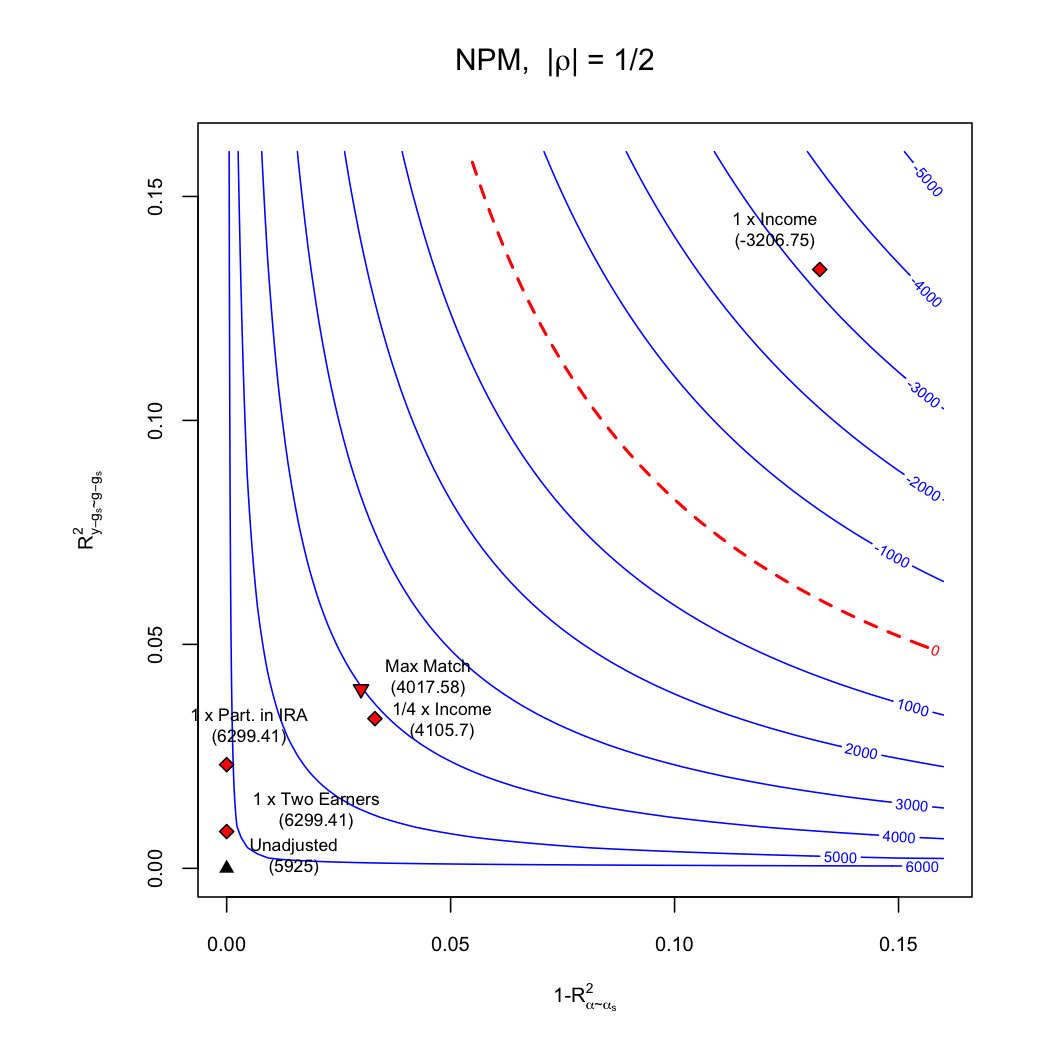

In [22]:
pdf("figures/401K-contour-npm-lower-rho2.pdf", width = 6, height = 6)
contour_panel(dml.401k.npm, out.npm, rho2 = rho2.half, title = expression(paste("NPM,  |", rho, "| = 1/2")), bumps = bumps.npm)
invisible(dev.off())

contour_panel(dml.401k.npm, out.npm, rho2 = rho2.half, title = expression(paste("NPM,  |", rho, "| = 1/2")), bumps = bumps.npm)

The nonparametric contours are slightly more conservative, but the message is similar. Under perfect adversarial alignment, income-strength confounding can overturn the finding; the contextual matching scenario cannot. At $|\rho| = 1/2$, even the lower confidence endpoint for the main scenario remains comfortably positive.

The treatment-side gains for IRA participation and two-earner status come out near zero here, placing both markers on the vertical axis. This follows from what `gain.D` measures in this model: a covariate that barely moves propensity scores away from the middle of $[0,1]$ leaves average precision almost unchanged, however much it predicts the outcome.
